In [2]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns; sns.set()

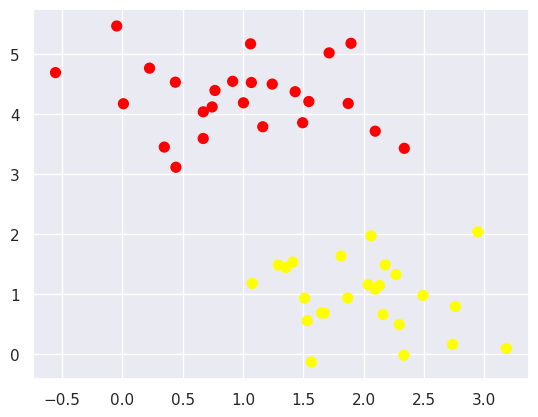

In [3]:
from sklearn.datasets import make_blobs
X,y = make_blobs(n_samples=50, centers=2, random_state=0, cluster_std=0.60)
plt.scatter(X[:,0], X[:,1], c=y, s=50, cmap='autumn')

In [4]:
from sklearn.svm import SVC
model = SVC(kernel='linear', C=1)
model.fit(X,y)

SVC(C=1, kernel='linear')

In [5]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Create a high-resolution grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 100)
    y = np.linspace(ylim[0], ylim[1], 100)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T

    # Predict on the grid points
    Z = model.predict(xy).reshape(X.shape)

    # Plot decision boundary and margins
    ax.contour(X, Y, model.decision_function(xy).reshape(X.shape), colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # Plot the colored regions with slightly adjusted alpha
    ax.contourf(X, Y, Z, cmap='bwr', alpha=0.4)

    # Plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none', edgecolors='black');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

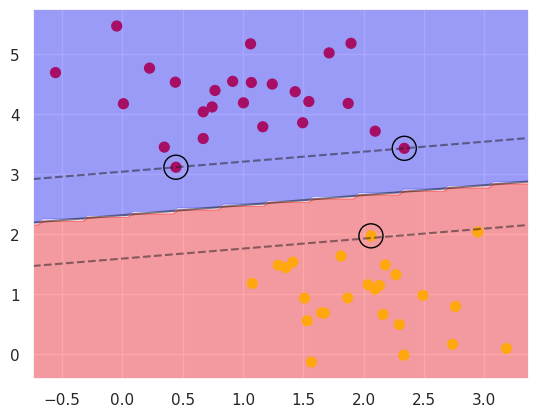

In [6]:
plt.scatter(X[:,0], X[:,1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(model)

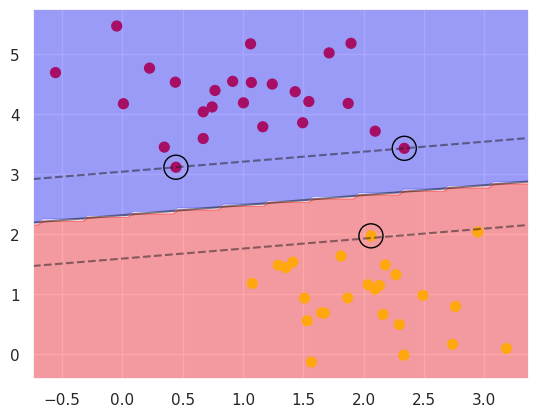

In [7]:
plt.scatter(X[:,0], X[:,1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(model)
plt.show()

In [8]:
# Generate a new dataset with 120 points
X2, y2 = make_blobs(n_samples=120, centers=2, random_state=0, cluster_std=0.60)

# Train a new SVC model for the 120 points
model2 = SVC(kernel='linear', C=1)
model2.fit(X2, y2)

SVC(C=1, kernel='linear')

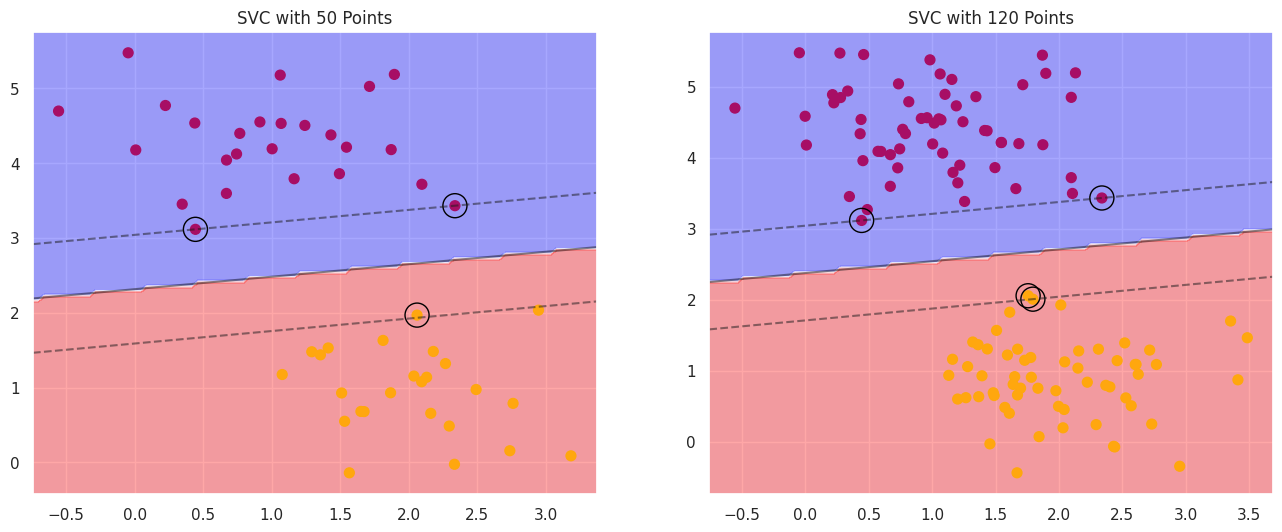

In [9]:
# Create two subplots
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot for 50 points (original data and model)
ax[0].scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(model, ax[0])
ax[0].set_title('SVC with 50 Points')

# Plot for 120 points (new data and model)
ax[1].scatter(X2[:, 0], X2[:, 1], c=y2, s=50, cmap='autumn')
plot_svc_decision_function(model2, ax[1])
ax[1].set_title('SVC with 120 Points')

plt.show()

## Working with Almost Linearly Seperable Data



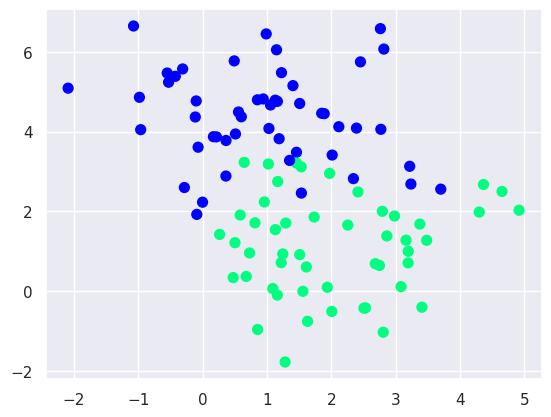

In [11]:
X,y = make_blobs(n_samples=100, centers=2, random_state=0, cluster_std=1.2)
plt.scatter(X[:,0], X[:,1], c=y, s=50, cmap='winter')
#

In [14]:
model_C1 = SVC(kernel='linear', C=10).fit(X, y)
model_C0_1 = SVC(kernel='linear', C=0.1).fit(X, y)

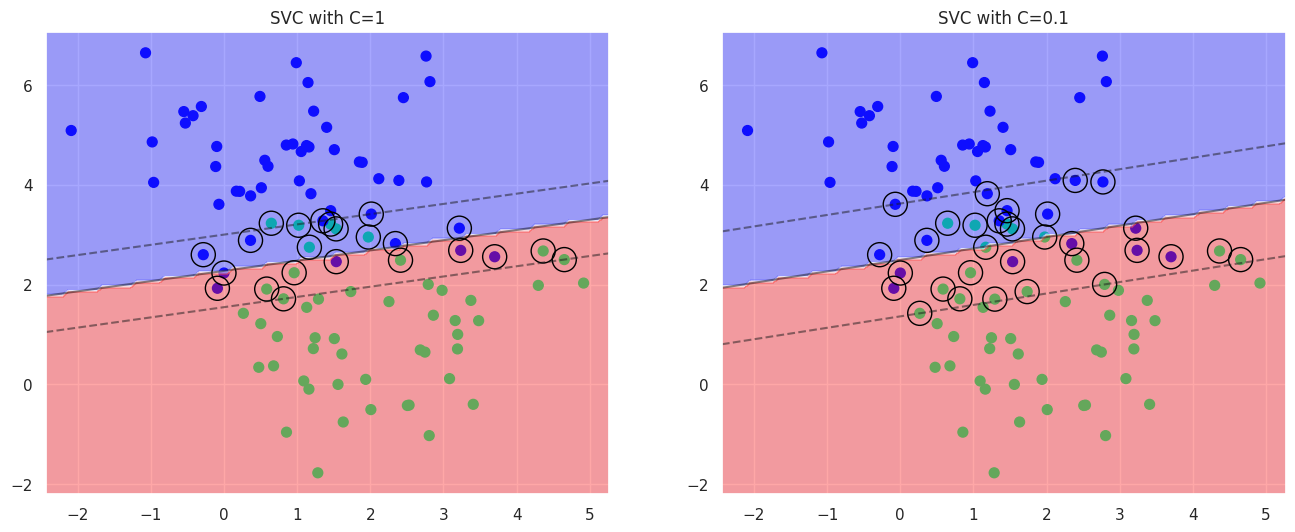

In [18]:
# Create two subplots to compare the models
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot for C=1
ax[0].scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
plot_svc_decision_function(model_C1, ax[0])
ax[0].set_title('SVC with C=1')

# Plot for C=0.1
ax[1].scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
plot_svc_decision_function(model_C0_1, ax[1])
ax[1].set_title('SVC with C=0.1')

plt.show()